### Language Confidence Score
To assess the likelihood that the words collected by count_words method belong to a specific language, I will utilize the Mean Squared Error (MSE) metric. This involves comparing the normalized frequencies (Zipf values) of the top $k$ words in the target language against the frequencies of those same words found in the scraped dictionary.

**Note:** Since the task requires the score to increase as the fit improves, I'm not using raw MSE - rather that I'm using $((MAX\_MSE - MSE) / MAX\_MSE) * 100$, where $MAX\_MSE$ is 81 (since max value for zipf is 9).

In [25]:
def lang_confidence_score(word_counts_zipf, language_words_with_frequency):
    """Counts confidence, that word_counts is in the same language as language_words_with_frequency.

    :param word_counts_zipf: dictionary of words from the article with their frequency in zipf
    :param language_words_with_frequency: dictionary of top n words from candidate language
    """
    MAX_MSE = 81
    MSE = 0
    count = 0
    for word in language_words_with_frequency:
        MSE += (word_counts_zipf.get(word, 0) - language_words_with_frequency.get(word, 0))**2
        count += 1

    MSE /= count

    confidence = ((MAX_MSE - MSE) /  MAX_MSE) * 100
    confidence = round(confidence, 2)
    return confidence

Next, I will collect data from:
- a longer article on Bulbapedia
- really short article on Bulbapedia
- article outside of Bulbapedia in English, Spanish and Polish.

All of them to evaluate the effectiveness of the proposed function on a few dataset.

In [26]:
from scraper_class import calc_zipf
def get_lang_scores_data(zipf_wiki):

    ks = [3, 10, 100, 1000]
    scores_en = []
    scores_es = []
    scores_pl = []

    for k in ks:
        en_top_words = wf.top_n_list('en', k)
        es_top_words = wf.top_n_list('es', k)
        pl_top_words = wf.top_n_list('pl', k)

        dict_en = {}
        dict_es = {}
        dict_pl = {}

        for word in en_top_words:
            dict_en[word] = wf.zipf_frequency(word, 'en', wordlist='small')

        for word in es_top_words:
            dict_es[word] = wf.zipf_frequency(word, 'es', wordlist='small')

        for word in pl_top_words:
            dict_pl[word] = wf.zipf_frequency(word, 'pl', wordlist='small')

        scores_en.append(lang_confidence_score(zipf_wiki, dict_en))
        scores_es.append(lang_confidence_score(zipf_wiki, dict_es))
        scores_pl.append(lang_confidence_score(zipf_wiki, dict_pl))

    return ks, scores_en, scores_es, scores_pl

def get_zipf(scraper):
    article_count = scraper.count_words()
    words_total = sum(article_count.values())

    article_zipf = {}
    for word, count in article_count.items():
        zipf = calc_zipf(count, words_total)
        article_zipf[word] = zipf
    return article_zipf

In [27]:
from scraper_class import WikiScraper
import wordfreq as wf

print("=== CASE 1. LARGE WIKI ARTICLE ===", flush=True)
scraper = WikiScraper('https://bulbapedia.bulbagarden.net/wiki/', "Poké_Ball")
article_zipf_large = get_zipf(scraper)

print("=== CASE 2. SMALL WIKI ARTICLE ===", flush=True)
scraper = WikiScraper("https://bulbapedia.bulbagarden.net/wiki/", "Basement_Key_(Johto)")
article_zipf_small = get_zipf(scraper)

print("=== CASE 3. OTHER ENGLISH ARTICLE ===", flush=True)
scraper = WikiScraper("https://creativecommons.org/share-your-work/cclicenses/", "english_article", True)
assert scraper.check_html() == True
article_zipf_en = get_zipf(scraper)

print("=== CASE 4. OTHER SPANISH ARTICLE ===", flush=True)
scraper = WikiScraper("https://creativecommons.org/licenses/by-nc-sa/4.0/legalcode.es", "spanish_article", True)
assert scraper.check_html() == True
article_zipf_es = get_zipf(scraper)

print("=== CASE 5. OTHER POLISH ARTICLE ===", flush=True)
scraper = WikiScraper("https://creativecommons.org/licenses/by-nc-sa/4.0/legalcode.pl", "polish_article", True)
assert scraper.check_html() == True
article_zipf_pl = get_zipf(scraper)

=== CASE 5. OTHER POLISH ARTICLE ===


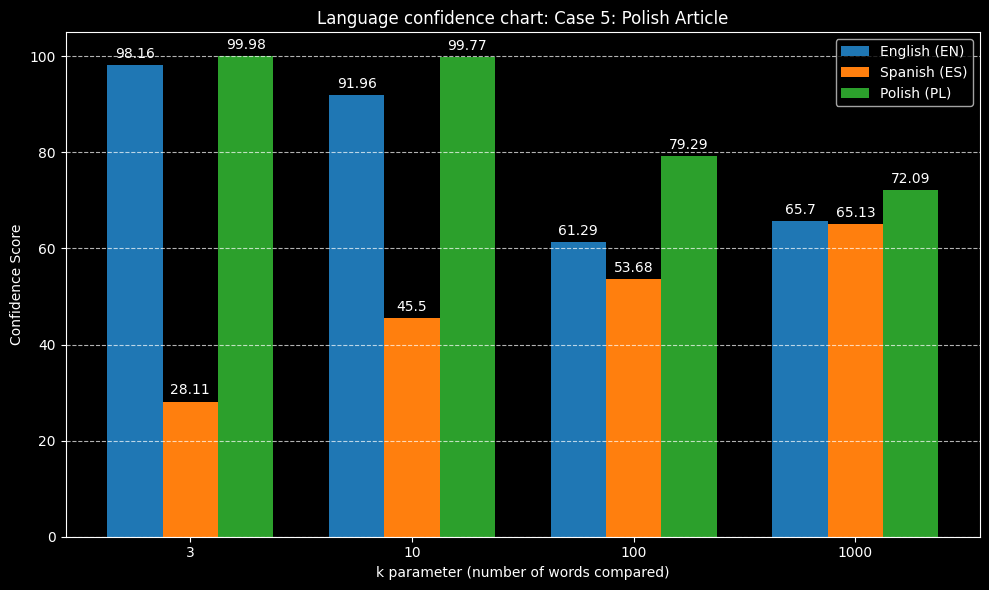

In [28]:
import matplotlib.pyplot as plt
import numpy as np

cases = [
    ("Case 1: Large Wiki Article (Poké Ball)", article_zipf_large),
    ("Case 2: Small Wiki Article (Basement Key)", article_zipf_small),
    ("Case 3: English Article", article_zipf_en),
    ("Case 4: Spanish Article", article_zipf_es),
    ("Case 5: Polish Article", article_zipf_pl)
]

for title, article_data in cases:
    ks, en, es, pl = get_lang_scores_data(article_data)

    x = np.arange(len(ks))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))

    # Bar drawing.
    rects1 = ax.bar(x - width, en, width, label='English (EN)', color='#1f77b4')
    rects2 = ax.bar(x, es, width, label='Spanish (ES)', color='#ff7f0e')
    rects3 = ax.bar(x + width, pl, width, label='Polish (PL)', color='#2ca02c')

    # legend, labels etc.
    ax.set_ylabel('Confidence Score')
    ax.set_xlabel('k parameter (number of words compared)')
    ax.set_title(f'Language confidence chart: {title}')
    # adding k values to x-axis
    ax.set_xticks(x)
    ks = [str(k) for k in ks]
    ax.set_xticklabels(ks)
    ax.legend()

    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # labels above the bars
    ax.bar_label(rects1, padding=3)
    ax.bar_label(rects2, padding=3)
    ax.bar_label(rects3, padding=3)

    fig.tight_layout()
    plt.savefig(title + '.png')

The results indicate that the language detection function performs reasonably well. For longer articles, the confidence score remains consistently high. However, for shorter texts, the confidence tends to decrease as $k$ increases. Interestingly, in the case of the short wiki article, this trend is not strictly monotonic. This leads to the hypothesis that the optimal value of $k$ depends on both the length of the text and the diversity of the article.

Although Polish is a morphologically rich language, its scores did not differ significantly from those of Spanish or English article. Regarding the outlier analysis, finding an article where the English confidence score was strictly the lowest was difficult. Instead, I selected an article where the score dropped most rapidly. To achieve this, I searched for short articles describing single-use items, such as keys. For $k=1000$, the score for this article became equal to the scores of other languages, effectively minimizing the distinction between the target language and others.

**The relatively high English language scores observed for Polish and Spanish articles may be attributed to the presence of English artifacts within the article. But, even with them my function was able to distinguish correct language with the highest confidence.**